# Análisis de Vulnerabilidad Demográfica Covid-19 Perú

### Contexto del proyecto

El dataset a trabajar es: `covid_peru_limpio.csv` el cual fue preparado y limpiado de manera meticulosa. Este dataset contiene registros de casos **positivos de COVID-19 en Perú**.  
Las transformaciones ya aplicadas son:
- Conversión de `FECHA_RESULTADO` y `FECHA_CORTE` a tipo `datetime`
- `EDAD` convertida a tipo `Int64` y filtrada al rango 0–100
- Registros con nulos en variables críticas eliminados
- Duplicados eliminados
- Nueva columna `GRUPO_EDAD` con 6 categorías epidemiológicas
- Fechas inválidas (antes de 2020) eliminadas

**Variables clave para este análisis:** `EDAD`, `SEXO`, `DEPARTAMENTO`, `FECHA_RESULTADO`, `GRUPO_EDAD`

**Objetivo de negocio:** Identificar qué grupos demográficos y regiones son más vulnerables ante futuras olas, para orientar la asignación de recursos (UCI, vacunas, presupuesto).




---
## Fase 01: Carga, Verificacion y Analisis Inicial


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('./covid_peru_limpio.csv',sep=';')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4345522 entries, 0 to 4345521
Data columns (total 11 columns):
 #   Column           Dtype
---  ------           -----
 0   FECHA_CORTE      str  
 1   DEPARTAMENTO     str  
 2   PROVINCIA        str  
 3   DISTRITO         str  
 4   METODODX         str  
 5   EDAD             int64
 6   SEXO             str  
 7   FECHA_RESULTADO  str  
 8   UBIGEO           int64
 9   ID_PERSONA       int64
 10  GRUPO_EDAD       str  
dtypes: int64(3), str(8)
memory usage: 364.7 MB


In [3]:
# Convertir columna Grupo_Edad a Categoría
orden=[
    '0-17 años (Menores)',
    '18-29 años (Jóvenes)',
    '30-44 años (Adultos Jóvenes)',
    '45-59 años (Adultos)',
    '60-74 años (Adultos Mayores)',
    '75+ años (Tercera Edad)'
]
df['GRUPO_EDAD'] = pd.Categorical(df['GRUPO_EDAD'], categories=orden, ordered=True)
df['GRUPO_EDAD'].unique()

['45-59 años (Adultos)', '60-74 años (Adultos Mayores)', '18-29 años (Jóvenes)', '30-44 años (Adultos Jóvenes)', '75+ años (Tercera Edad)', '0-17 años (Menores)']
Categories (6, str): ['0-17 años (Menores)' < '18-29 años (Jóvenes)' < '30-44 años (Adultos Jóvenes)' < '45-59 años (Adultos)' < '60-74 años (Adultos Mayores)' < '75+ años (Tercera Edad)']

In [ ]:
# Formatear números decimales a dos dígitos
pd.options.display.float_format = '{:.2f}'.format
# Mostrar estadisticas clave del DataFrame
df.describe(include='all')

,FECHA_CORTE,DEPARTAMENTO,PROVINCIA,DISTRITO,METODODX,EDAD,SEXO,FECHA_RESULTADO,UBIGEO,ID_PERSONA,GRUPO_EDAD
count,4345522,4345522,4345522,4345522,4345522,4345522.00,4345522,4345522,4345522.00,4345522.00,4345522
unique,1,25,196,1704,3,NaN,2,1458,NaN,NaN,6
top,2024-12-03,LIMA,LIMA,LIMA,AG,NaN,FEMENINO,2022-01-19,NaN,NaN,30-44 años (Adultos Jóvenes)
freq,4345522,1991910,1882347,196917,2089821,NaN,2261081,56908,NaN,NaN,1418421
mean,NaN,NaN,NaN,NaN,NaN,40.73,NaN,NaN,129833.19,44220053.17,NaN
std,NaN,NaN,NaN,NaN,NaN,17.70,NaN,NaN,53241.72,2064819.57,NaN
min,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,10101.00,2130.00,NaN
25%,NaN,NaN,NaN,NaN,NaN,28.00,NaN,NaN,100102.00,43146959.25,NaN
50%,NaN,NaN,NaN,NaN,NaN,39.00,NaN,NaN,150110.00,44293464.50,NaN
75%,NaN,NaN,NaN,NaN,NaN,53.00,NaN,NaN,150135.00,45437001.75,NaN


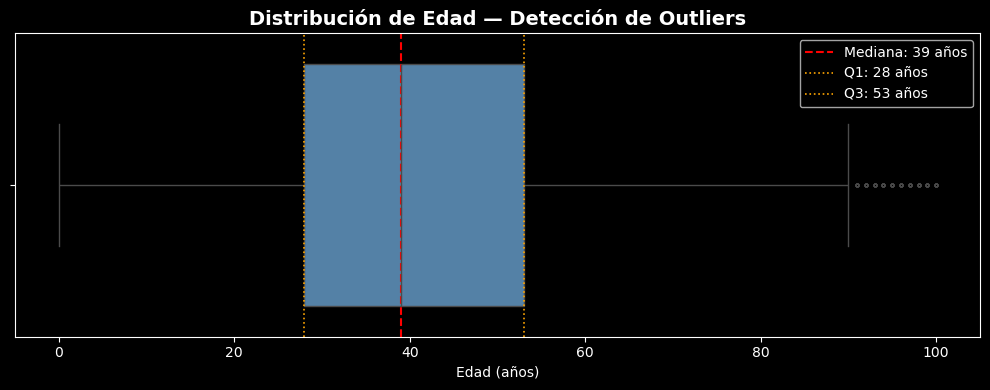

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(x='EDAD', data=df, ax=ax, color='steelblue', flierprops=dict(marker='o', markersize=2, alpha=0.3))

ax.set_title('Distribución de Edad — Detección de Outliers', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad (años)')

q1, mediana, q3 = df['EDAD'].quantile([0.25, 0.50, 0.75])
ax.axvline(mediana, color='red', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.0f} años')
ax.axvline(q1, color='orange', linestyle=':', linewidth=1.2, label=f'Q1: {q1:.0f} años')
ax.axvline(q3, color='orange', linestyle=':', linewidth=1.2, label=f'Q3: {q3:.0f} años')
ax.legend()

plt.tight_layout()
plt.show()


---
## Fase 02: Graficas estaticas
### Gráfica 1 -Nro de casos por grupo de edad
#### Muestra el numero de contagios de Covid por categoria de edad, muestra que grupo poblacional fue el mas afectado  

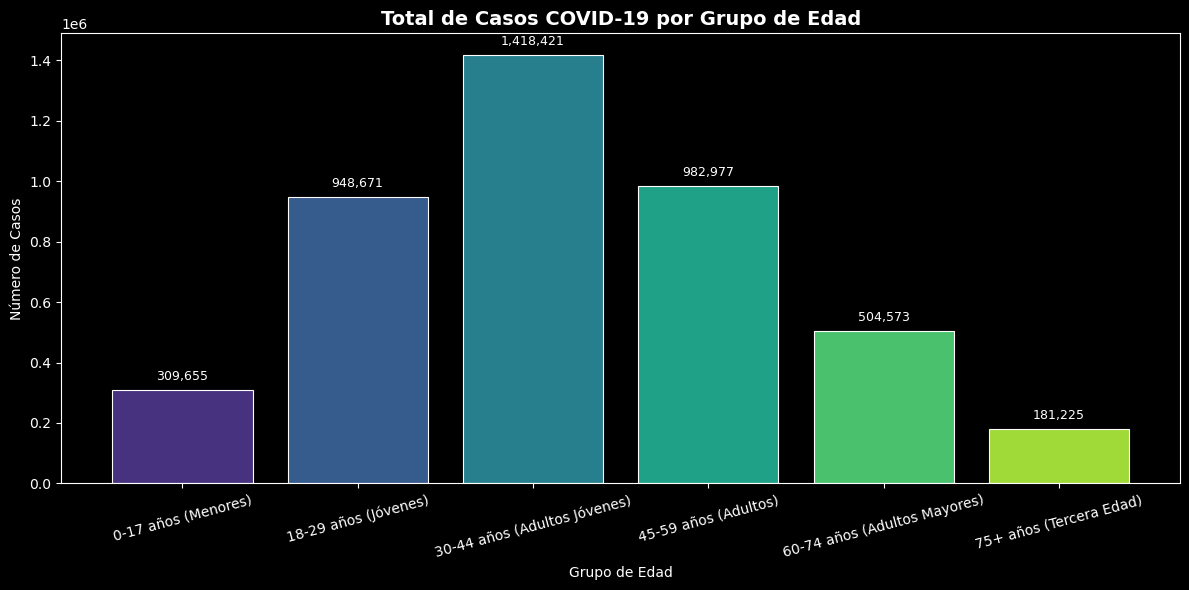

In [ ]:
conteo_grupos = df['GRUPO_EDAD'].value_counts().reindex(orden)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    conteo_grupos.index,  
    conteo_grupos.values, 
    color=sns.color_palette('viridis', len(orden)),  
    edgecolor='white',
    linewidth=0.8
)

ax.bar_label(bars, fmt='{:,.0f}', padding=5, fontsize=9)

ax.set_title('Total de Casos COVID-19 por Grupo de Edad', fontsize=14, fontweight='bold')
ax.set_xlabel('Grupo de Edad')
ax.set_ylabel('Número de Casos')
ax.tick_params(axis='x', rotation=15)  

plt.tight_layout()
plt.show()

### Grafica 2 - Casos por sexo
#### Muestra la diferencia entre el numero de contagios entre hombres y mujeres de la muestra en dos casos: General y por Categoria de edad 

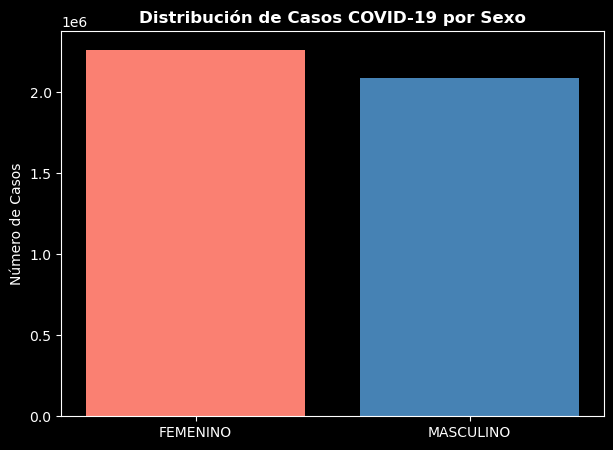

In [24]:
plt.figure(figsize=(7, 5))

conteo = df['SEXO'].value_counts()

plt.bar(conteo.index, conteo.values, color=['salmon', 'steelblue'])

plt.title('Distribución de Casos COVID-19 por Sexo', fontweight='bold')
plt.ylabel('Número de Casos')

plt.show()


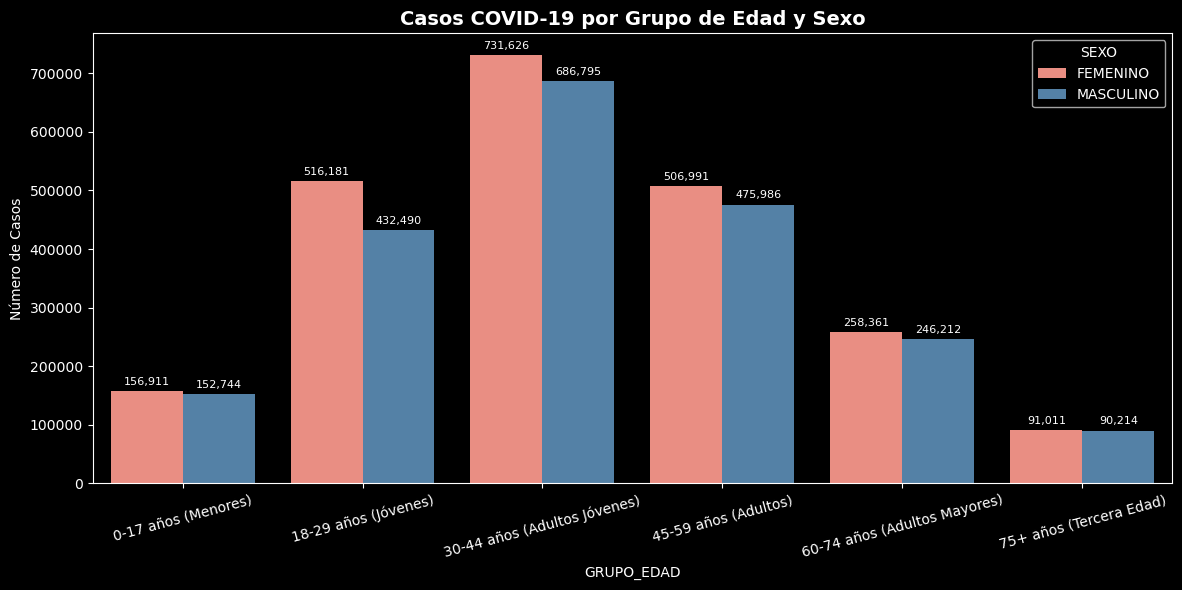

In [23]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df, 
    x='GRUPO_EDAD', 
    y=df.index, 
    hue='SEXO', 
    order=orden,
    palette=['salmon', 'steelblue'], 
    estimator=len 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=8)

ax.set_title('Casos COVID-19 por Grupo de Edad y Sexo', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Casos')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


### Grafica 3-Departamentos con mas contagios
#### Muestra el top10 de departementos con mas contagios registrados 

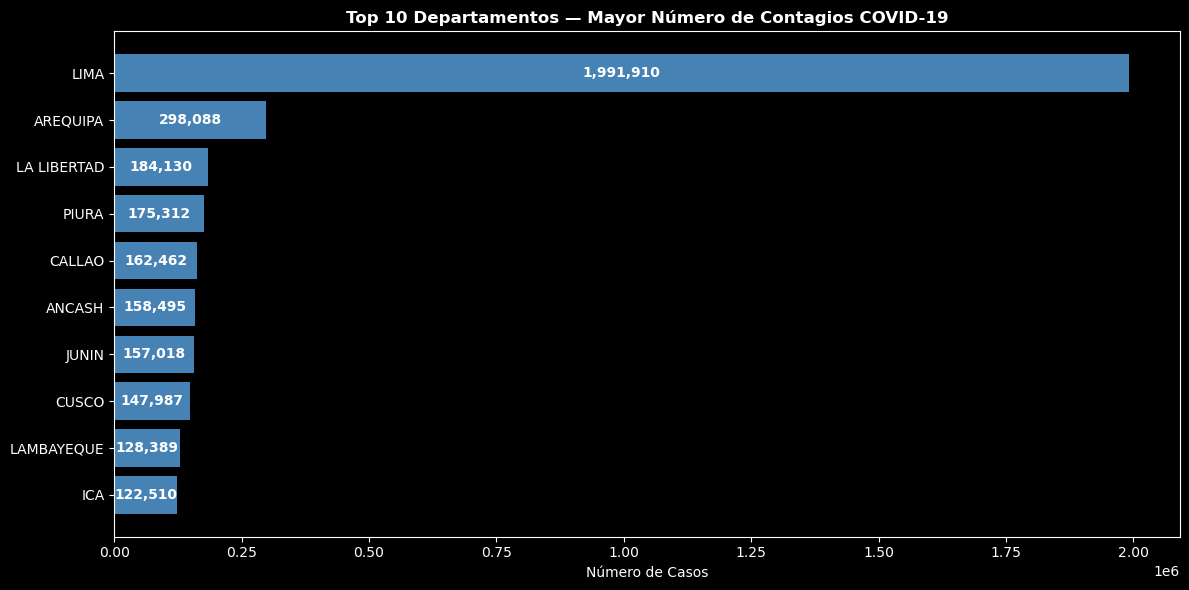

In [ ]:
top10_deptos = df['DEPARTAMENTO'].value_counts().nlargest(10).sort_values()


fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_deptos.index, top10_deptos.values, color='steelblue')

ax.bar_label(bars, fmt='{:,.0f}', label_type='center', color='white', fontweight='bold')


ax.set_title('Top 10 Departamentos — Mayor Número de Contagios COVID-19', fontweight='bold')
ax.set_xlabel('Número de Casos')
plt.tight_layout()
plt.show()


#### Muestra el top10 de departamentos mas afectados(%) 

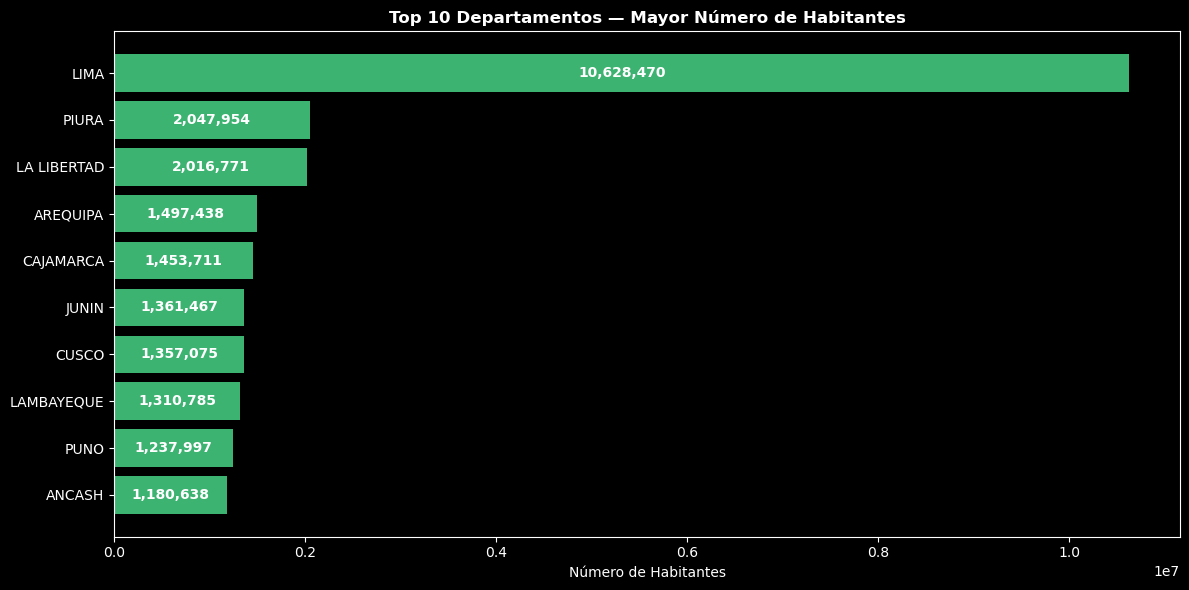

In [12]:
# DataFrame con datos de población por departamento promedio en 2020-2022 
data_poblacion = {
    'DEPARTAMENTO': [
        'AMAZONAS', 'ANCASH', 'APURIMAC', 'AREQUIPA', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 
        'HUANCAVELICA', 'HUANUCO', 'ICA', 'JUNIN', 'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA', 'LORETO', 
        'MADRE DE DIOS', 'MOQUEGUA', 'PASCO', 'PIURA', 'PUNO', 'SAN MARTIN', 'TACNA', 'TUMBES', 'UCAYALI'
    ],
    'POBLACION': [
        426806, 1180638, 430736, 1497438, 668213, 1453711, 1129854, 1357075, 
        348831, 721047, 975182, 1361467, 2016771, 1310785, 10628470, 883510, 
        173811, 192742, 271904, 2047954, 1237997, 899648, 370974, 251521, 589110
    ]
}
df_pob = pd.DataFrame(data_poblacion)
deptos_pob = df_pob.nlargest(10, 'POBLACION').sort_values('POBLACION', ascending=True)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(deptos_pob['DEPARTAMENTO'], deptos_pob['POBLACION'], color='mediumseagreen')

ax.bar_label(bars, fmt='{:,.0f}', label_type='center', color='white', fontweight='bold')


ax.set_title('Top 10 Departamentos — Mayor Número de Habitantes', fontweight='bold')
ax.set_xlabel('Número de Habitantes')
plt.tight_layout()
plt.show()


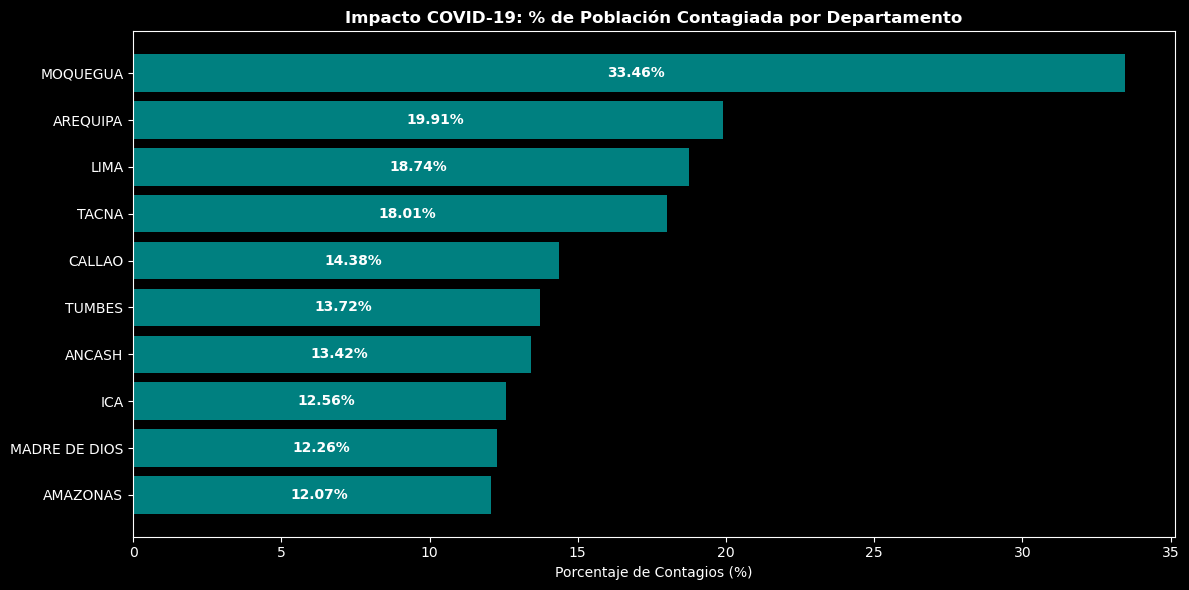

In [9]:
contagios_deptos = df['DEPARTAMENTO'].value_counts().reset_index()
contagios_deptos.columns = ['DEPARTAMENTO', 'CONTAGIOS']

df_analisis = pd.merge(contagios_deptos, df_pob, on='DEPARTAMENTO')

df_analisis['PORCENTAJE'] = (df_analisis['CONTAGIOS'] / df_analisis['POBLACION']) * 100

df_analisis = df_analisis.nlargest(10, 'PORCENTAJE').sort_values('PORCENTAJE', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_analisis['DEPARTAMENTO'], df_analisis['PORCENTAJE'], color='teal')

ax.bar_label(bars, fmt='%.2f%%', label_type='center', padding=5, fontweight='bold')

ax.set_title('Impacto COVID-19: % de Población Contagiada por Departamento', fontweight='bold')
ax.set_xlabel('Porcentaje de Contagios (%)')
plt.tight_layout()
plt.show()


In [10]:
# Calcular Tasa por cada 100,000 habitantes
df_analisis['Tasa_100k_Hab'] = (df_analisis['CONTAGIOS'] / df_analisis['POBLACION']) * 100000

tabla_tasas = df_analisis[['DEPARTAMENTO', 'Tasa_100k_Hab']].sort_values(by='Tasa_100k_Hab', ascending=False)

print("TABLA DE INCIDENCIA POR DEPARTAMENTO")
print(tabla_tasas.to_string(index=False, formatters={
    'Tasa_100k_Hab': '{:,.0f}'.format
}))


TABLA DE INCIDENCIA POR DEPARTAMENTO
 DEPARTAMENTO Tasa_100k_Hab
     MOQUEGUA        33,465
     AREQUIPA        19,907
         LIMA        18,741
        TACNA        18,012
       CALLAO        14,379
       TUMBES        13,724
       ANCASH        13,425
          ICA        12,563
MADRE DE DIOS        12,263
     AMAZONAS        12,069


---
## Fase 03: Conclusiones 

### 3.1 Grupos Demográficos mas Vulnerables

**Por volumen de contagios:**
- El grupo `30-44 años (Adultos Jóvenes)` concentró el mayor número de contagios
- En términos de sexo, `MASCULINO/FEMENINO` el grupo femenino fue el mas afectado siendo el de adultos jovenes(30-44 años) el que presentaba mas casos registrados.

**Conclusión:**
Los grupos con más casos no son necesariamente los más "vulnerables" en términos de gravedad clínica. Los adultos mayores y tercera edad, aunque con menos casos positivos, tienen mayor tasa de hospitalización y mortalidad.

---

### 3.2 Regiones Criticas

**Top 3 departamentos con mayor carga de contagios:**
1. `Lima` — `1,991,910` casos
2. `Arequipa` — `298,088` casos
3. `La Libertad` — `184,130` casos

**Conclusión:**  La concentración de casos en Lima es esperable dado que concentra aprox 35% de la población peruana. 